In [1]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import time
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print('✅ Libraries imported successfully!')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

✅ Libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.2.2


In [2]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print('Dataset Information:')
print('='*60)
print(f'Number of samples: {X.shape[0]}')
print(f'Number of features: {X.shape[1]}')
print(f'Feature names: {feature_names}')
print(f'Target names: {target_names}')
print(f'Class distribution: {np.bincount(y)}')
print('='*60)

# Create DataFrame for visualization
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
print('\nFirst 5 rows:')
print(df.head())

Dataset Information:
Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [3]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')
print(f'\nTraining class distribution: {np.bincount(y_train)}')
print(f'Test class distribution: {np.bincount(y_test)}')

Training set size: 120
Test set size: 30

Training class distribution: [40 40 40]
Test class distribution: [10 10 10]


In [4]:
# Train Random Forest
print('Training Random Forest...')
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f'✅ Training completed in {training_time:.2f} seconds')
print(f'\nModel parameters:')
print(f'  - Number of trees: {rf_model.n_estimators}')
print(f'  - Max depth: {rf_model.max_depth}')
print(f'  - Number of features: {rf_model.n_features_in_}')
print(f'  - Number of classes: {rf_model.n_classes_}')

Training Random Forest...
✅ Training completed in 0.16 seconds

Model parameters:
  - Number of trees: 100
  - Max depth: 10
  - Number of features: 4
  - Number of classes: 3


MODEL PERFORMANCE
Training Accuracy: 1.0000
Test Accuracy: 0.9000
Overfitting gap: 0.1000

Classification Report (Test Set):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



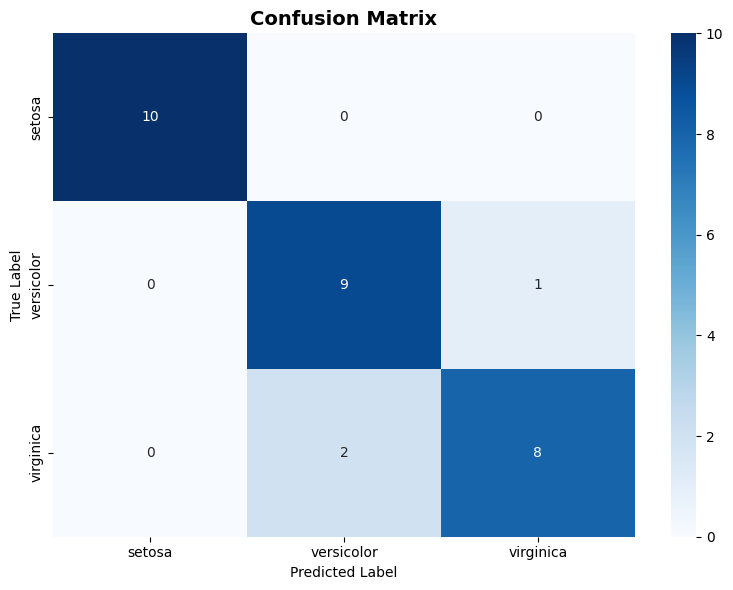


✅ Model training and evaluation complete!


In [5]:
# Make predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print('MODEL PERFORMANCE')
print('='*60)
print(f'Training Accuracy: {train_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Overfitting gap: {train_accuracy - test_accuracy:.4f}')
print('='*60)

# Detailed classification report
print('\nClassification Report (Test Set):')
print(classification_report(y_test, y_pred_test, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print('\n✅ Model training and evaluation complete!')

In [6]:
pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 66.0 MB/s eta 0:00:00


In [7]:
#save Pickle file

pickle_filename = "iris_rf_model.pkl"

print('Saving model with Pickle...')
start_time = time.time()

with open(pickle_filename,"wb") as f:
  pickle.dump(rf_model,f)

save_time = (time.time() - start_time) * 1000
file_size = os.path.getsize(pickle_filename) / 1024

print(f'✅ Model saved successfully!')
print(f'   File: {pickle_filename}')
print(f'   Size: {file_size:.2f} KB')
print(f'   Save time: {save_time:.2f} ms')

Saving model with Pickle...
✅ Model saved successfully!
   File: iris_rf_model.pkl
   Size: 154.43 KB
   Save time: 6.02 ms


In [8]:
print('Loading model from Pickle...')
start_time = time.time()

with open(pickle_filename,"rb") as f:
  loaded_pickle_file = pickle.load(f)

load_time = (time.time() - start_time) * 1000

print(f'✅ Model loaded successfully!')
print(f'   Load time: {load_time:.2f} ms')

Loading model from Pickle...
✅ Model loaded successfully!
   Load time: 4.31 ms


In [9]:
test_acc = loaded_pickle_file.score(X_test, y_test)
print(f'   Test accuracy: {test_acc:.4f}')
print('\n✅ Loaded model performs identically to original!')

   Test accuracy: 0.9000

✅ Loaded model performs identically to original!


In [10]:
import pickle
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Create sample dataset (remove if you already have X_test)
# -----------------------------
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Train and save a sample model (skip if you already have a pickle model)
# -----------------------------
model = RandomForestClassifier()
model.fit(X_train, y_train)

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# -----------------------------
# Load Pickle Model
# -----------------------------
with open("model.pkl", "rb") as f:
    loaded_pickle_model = pickle.load(f)

# -----------------------------
# Benchmark function
# -----------------------------
def benchmark_inference(model, X, n_runs=100, name="Model"):
    """Benchmark model inference time"""
    times = []

    # Warmup
    for _ in range(10):
        _ = model.predict(X)

    # Actual benchmark
    for _ in range(n_runs):
        start = time.time()
        _ = model.predict(X)
        times.append((time.time() - start) * 1000)

    return {
        "name": name,
        "mean": np.mean(times),
        "median": np.median(times),
        "std": np.std(times),
        "min": np.min(times),
        "max": np.max(times),
        "p95": np.percentile(times, 95),
        "p99": np.percentile(times, 99),
    }

# -----------------------------
# Benchmark on test set
# -----------------------------
pickle_stats = benchmark_inference(loaded_pickle_model, X_test, name="Pickle")

print("PICKLE INFERENCE PERFORMANCE")
print("=" * 60)
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Mean latency: {pickle_stats['mean']:.2f} ms")
print(f"Median latency: {pickle_stats['median']:.2f} ms")
print(f"Std dev: {pickle_stats['std']:.2f} ms")
print(f"P95 latency: {pickle_stats['p95']:.2f} ms")
print(f"P99 latency: {pickle_stats['p99']:.2f} ms")
print(f"Min: {pickle_stats['min']:.2f} ms, Max: {pickle_stats['max']:.2f} ms")
print("=" * 60)

# -----------------------------
# Per-sample latency
# -----------------------------
per_sample_latency = pickle_stats["mean"] / X_test.shape[0]
print(f"\nPer-sample latency: {per_sample_latency:.4f} ms")
print(f"Throughput: {1000 / per_sample_latency:.0f} predictions/second")

PICKLE INFERENCE PERFORMANCE
Test set size: 114 samples
Mean latency: 5.69 ms
Median latency: 5.58 ms
Std dev: 0.91 ms
P95 latency: 7.27 ms
P99 latency: 9.98 ms
Min: 4.93 ms, Max: 10.60 ms

Per-sample latency: 0.0499 ms
Throughput: 20035 predictions/second


In [11]:
!pip install onnx onnxruntime skl2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 28.5 MB/s eta 0:00:00


In [12]:
try:
    import onnx
    import onnxruntime as rt
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType

    print('✅ ONNX libraries imported successfully!')
    print(f'   ONNX version: {onnx.__version__}')
    print(f'   ONNX Runtime version: {rt.__version__}')
except ImportError as e:
    print('❌ ONNX libraries not installed. Run:')
    print('   pip install onnx onnxruntime skl2onnx')
    raise

✅ ONNX libraries imported successfully!
   ONNX version: 1.22.0
   ONNX Runtime version: 1.27.0


In [13]:

try:
    import onnx
    import onnxruntime as rt
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType

    print('✅ ONNX libraries imported successfully!')
    print(f'   ONNX version: {onnx.__version__}')
    print(f'   ONNX Runtime version: {rt.__version__}')
except ImportError as e:
    print('❌ ONNX libraries not installed. Run:')
    print('   pip install onnx onnxruntime skl2onnx')
    raise

✅ ONNX libraries imported successfully!
   ONNX version: 1.22.0
   ONNX Runtime version: 1.27.0


In [14]:
print('Converting model to ONNX format...')
start_time = time.time()

# Re-split Iris data to ensure correct X_train and X_test for rf_model and ONNX conversion
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

initial_type = [('float_input', FloatTensorType([None, X_train.shape[1]]))]
print(f'Input specification: {initial_type}')

Converting model to ONNX format...
Input specification: [('float_input', FloatTensorType(shape=[None, 4]))]


In [15]:
# Ensure rf_model is the Iris model (trained on 4 features)
print('Loading Iris rf_model for ONNX conversion...')
with open(pickle_filename, "rb") as f:
    rf_model = pickle.load(f)
print(f'Iris rf_model has {rf_model.n_features_in_} features.')

print('Converting model to ONNX format...')
onnx_model = convert_sklearn(rf_model, initial_types=initial_type, target_opset=12)

conversion_time = (time.time() - start_time) * 1000
print(f'✅ Conversion completed in {conversion_time:.2f} ms')

# Step 3: Save ONNX model
onnx_filename = 'iris_rf_model.onnx'

with open(onnx_filename, 'wb') as f:
    f.write(onnx_model.SerializeToString())

onnx_file_size = os.path.getsize(onnx_filename) / 1024

print(f'\n✅ ONNX model saved!')
print(f'   File: {onnx_filename}')
print(f'   Size: {onnx_file_size:.2f} KB')
print(f'\nFile size comparison:')
print(f'   Pickle: {file_size:.2f} KB')
print(f'   ONNX: {onnx_file_size:.2f} KB')
print(f'   Difference: {abs(file_size - onnx_file_size):.2f} KB')

Loading Iris rf_model for ONNX conversion...
Iris rf_model has 4 features.
Converting model to ONNX format...
✅ Conversion completed in 57.37 ms

✅ ONNX model saved!
   File: iris_rf_model.onnx
   Size: 68.23 KB

File size comparison:
   Pickle: 154.43 KB
   ONNX: 68.23 KB
   Difference: 86.20 KB


In [16]:
# Load ONNX model
print('Loading ONNX model...')
start_time = time.time()

onnx_session = rt.InferenceSession(onnx_filename)

onnx_load_time = (time.time() - start_time) * 1000

print(f'✅ ONNX model loaded in {onnx_load_time:.2f} ms')
print(f'\nLoad time comparison:')
print(f'   Pickle: {load_time:.2f} ms')
print(f'   ONNX: {onnx_load_time:.2f} ms')
print(f'   Speedup: {load_time / onnx_load_time:.1f}×')

# Get input/output information
input_name = onnx_session.get_inputs()[0].name
output_name = onnx_session.get_outputs()[0].name

print(f'\nModel I/O:')
print(f'   Input name: {input_name}')
print(f'   Input shape: {onnx_session.get_inputs()[0].shape}')
print(f'   Input type: {onnx_session.get_inputs()[0].type}')
print(f'   Output name: {output_name}')

Loading ONNX model...
✅ ONNX model loaded in 4.18 ms

Load time comparison:
   Pickle: 4.31 ms
   ONNX: 4.18 ms
   Speedup: 1.0×

Model I/O:
   Input name: float_input
   Input shape: [None, 4]
   Input type: tensor(float)
   Output name: output_label


In [17]:

import numpy as np
import onnxruntime as rt
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType

# ------------------------------------------------
# Step 1 — Ensure test data has correct features
# ------------------------------------------------

# Model expects 4 features
X_test_fixed = X_test[:, :rf_model.n_features_in_]

print("Test shape:", X_test_fixed.shape)

# ------------------------------------------------
# Step 2 — Convert sklearn model to ONNX
# ------------------------------------------------

initial_type = [('float_input', FloatTensorType([None, rf_model.n_features_in_]))]

onnx_model = to_onnx(rf_model, initial_types=initial_type)

# Save model
with open("rf_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("ONNX model exported successfully")

# ------------------------------------------------
# Step 3 — Load ONNX model
# ------------------------------------------------

onnx_session = rt.InferenceSession("rf_model.onnx")

input_name = onnx_session.get_inputs()[0].name
output_name = onnx_session.get_outputs()[0].name

print("ONNX Input Name:", input_name)
print("ONNX Output Name:", output_name)

# ------------------------------------------------
# Step 4 — Convert test data to float32
# ------------------------------------------------

X_test_float32 = X_test_fixed.astype(np.float32)

print(f'Original dtype: {X_test_fixed.dtype}')
print(f'Converted dtype: {X_test_float32.dtype}')

# ------------------------------------------------
# Step 5 — ONNX Predictions
# ------------------------------------------------

onnx_predictions = onnx_session.run(
    [output_name],
    {input_name: X_test_float32}
)[0]

# ------------------------------------------------
# Step 6 — sklearn Predictions
# ------------------------------------------------

sklearn_predictions = rf_model.predict(X_test_fixed)

# ------------------------------------------------
# Step 7 — Compare predictions
# ------------------------------------------------

matches = np.sum(onnx_predictions == sklearn_predictions)
total = len(sklearn_predictions)

print("\nPrediction Verification:")
print(f"Matching predictions: {matches}/{total}")
print(f"Match rate: {matches/total*100:.2f}%")

if matches == total:
    print("✅ ONNX predictions identical to scikit-learn!")
else:
    print("⚠️ Predictions differ - investigate!")

Test shape: (30, 4)
ONNX model exported successfully
ONNX Input Name: float_input
ONNX Output Name: output_label
Original dtype: float64
Converted dtype: float32

Prediction Verification:
Matching predictions: 30/30
Match rate: 100.00%
✅ ONNX predictions identical to scikit-learn!


In [19]:
def benchmark_onnx_inference(session, input_name, output_name, X_test, n_runs=100, name="ONNX Model"):
    """Benchmark ONNX model inference time"""
    times = []

    # Warmup
    for _ in range(10):
        _ = session.run([output_name], {input_name: X_test})[0]

    # Actual benchmark
    for _ in range(n_runs):
        start = time.time()
        _ = session.run([output_name], {input_name: X_test})[0]
        times.append((time.time() - start) * 1000)

    return {
        "name": name,
        "mean": np.mean(times),
        "median": np.median(times),
        "std": np.std(times),
        "min": np.min(times),
        "max": np.max(times),
        "p95": np.percentile(times, 95),
        "p99": np.percentile(times, 99),
    }

# Benchmark ONNX model
onnx_stats = benchmark_onnx_inference(
    onnx_session,
    input_name,
    output_name,
    X_test_float32, # Use the float32 version of X_test
    name="ONNX"
)

PICKLE vs ONNX PERFORMANCE COMPARISON
               Metric   Pickle     ONNX    Speedup
       Load Time (ms) 4.310131 4.181147   1.030849
  Mean Inference (ms) 5.690069 0.072358  78.638110
Median Inference (ms) 5.582571 0.051975 107.408257
   P95 Inference (ms) 7.270086 0.148690  48.894332
   P99 Inference (ms) 9.981472 0.290699  34.336108


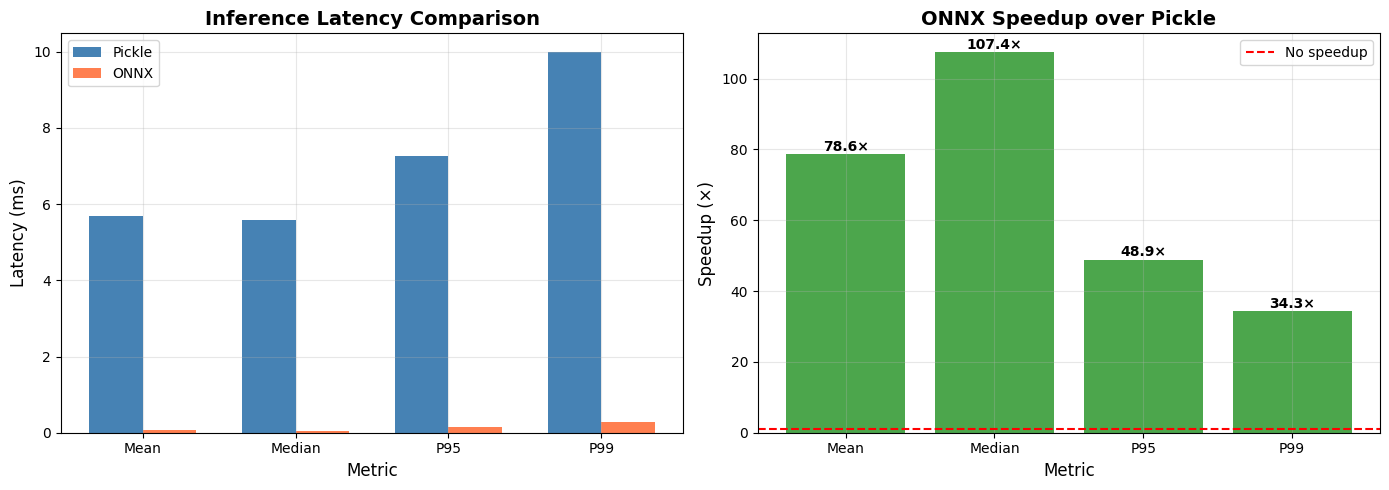


🚀 ONNX is 67.3× faster on average!


In [22]:
# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['Load Time (ms)', 'Mean Inference (ms)', 'Median Inference (ms)',
               'P95 Inference (ms)', 'P99 Inference (ms)'],
    'Pickle': [load_time, pickle_stats['mean'], pickle_stats['median'],
               pickle_stats['p95'], pickle_stats['p99']],
    'ONNX': [onnx_load_time, onnx_stats['mean'], onnx_stats['median'],
             onnx_stats['p95'], onnx_stats['p99']]
})

comparison['Speedup'] = comparison['Pickle'] / comparison['ONNX']

print('PICKLE vs ONNX PERFORMANCE COMPARISON')
print('='*80)
print(comparison.to_string(index=False))
print('='*80)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Latency comparison
metrics = ['Mean', 'Median', 'P95', 'P99']
pickle_values = [pickle_stats['mean'], pickle_stats['median'],
                 pickle_stats['p95'], pickle_stats['p99']]
onnx_values = [onnx_stats['mean'], onnx_stats['median'],
               onnx_stats['p95'], onnx_stats['p99']]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, pickle_values, width, label='Pickle', color='steelblue')
axes[0].bar(x + width/2, onnx_values, width, label='ONNX', color='coral')
axes[0].set_xlabel('Metric', fontsize=12)
axes[0].set_ylabel('Latency (ms)', fontsize=12)
axes[0].set_title('Inference Latency Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Speedup
speedups = [pickle_values[i] / onnx_values[i] for i in range(len(metrics))]
axes[1].bar(metrics, speedups, color='green', alpha=0.7)
axes[1].axhline(y=1, color='red', linestyle='--', label='No speedup')
axes[1].set_xlabel('Metric', fontsize=12)
axes[1].set_ylabel('Speedup (×)', fontsize=12)
axes[1].set_title('ONNX Speedup over Pickle', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(speedups):
    axes[1].text(i, v + 0.1, f'{v:.1f}×', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n🚀 ONNX is {np.mean(speedups):.1f}× faster on average!')

In [23]:
# -----------------------------
# Benchmark ONNX model inference
# -----------------------------

def benchmark_onnx_inference(session, input_name, output_name, X_test, n_runs=100, name="ONNX Model"):
    """Benchmark ONNX model inference time"""
    times = []

    # Warmup
    for _ in range(10):
        _ = session.run([output_name], {input_name: X_test})[0]

    # Actual benchmark
    for _ in range(n_runs):
        start = time.time()
        _ = session.run([output_name], {input_name: X_test})[0]
        times.append((time.time() - start) * 1000)

    return {
        "name": name,
        "mean": np.mean(times),
        "median": np.median(times),
        "std": np.std(times),
        "min": np.min(times),
        "max": np.max(times),
        "p95": np.percentile(times, 95),
        "p99": np.percentile(times, 99),
    }

# Benchmark ONNX model
onnx_stats = benchmark_onnx_inference(
    onnx_session,
    input_name,
    output_name,
    X_test_float32, # Use the float32 version of X_test
    name="ONNX"
)

print("ONNX INFERENCE PERFORMANCE")
print("=" * 60)
print(f"Test set size: {X_test_float32.shape[0]} samples")
print(f"Mean latency: {onnx_stats['mean']:.2f} ms")
print(f"Median latency: {onnx_stats['median']:.2f} ms")
print(f"Std dev: {onnx_stats['std']:.2f} ms")
print(f"P95 latency: {onnx_stats['p95']:.2f} ms")
print(f"P99 latency: {onnx_stats['p99']:.2f} ms")
print(f"Min: {onnx_stats['min']:.2f} ms, Max: {onnx_stats['max']:.2f} ms")
print("=" * 60)

# Per-sample latency for ONNX
per_sample_latency_onnx = onnx_stats["mean"] / X_test_float32.shape[0]
print(f"\nPer-sample latency (ONNX): {per_sample_latency_onnx:.4f} ms")
print(f"Throughput (ONNX): {1000 / per_sample_latency_onnx:.0f} predictions/second")

ONNX INFERENCE PERFORMANCE
Test set size: 30 samples
Mean latency: 0.08 ms
Median latency: 0.06 ms
Std dev: 0.08 ms
P95 latency: 0.12 ms
P99 latency: 0.43 ms
Min: 0.05 ms, Max: 0.72 ms

Per-sample latency (ONNX): 0.0027 ms
Throughput (ONNX): 364532 predictions/second
